In [1]:
import matplotlib.pyplot as plt
import numpy as np
import mat73
import scipy.signal as ss
from mpl_toolkits.axes_grid1 import make_axes_locatable
import os
from scipy import signal
plt.rcParams['font.size'] = 18

In [2]:
plt.rcParams['text.usetex'] =True
plt.rcParams['font.family'] = 'serif',
plt.rcParams['font.serif'] =  'Computer Modern'

In [6]:
cd D:

D:\


In [7]:
cd new_data_thalamus/

D:\new_data_thalamus


In [4]:
#os.chdir(path)
import warnings
warnings.filterwarnings("ignore")

## Loading the datasets

In [13]:
import os
import numpy as np
import scipy.signal as ss
import mat73

thalamus = True
if not thalamus:
    rat = 4
    file = os.listdir()[1:][rat]
    import mat73
    data_dict = mat73.loadmat(file)
    data = data_dict['amplifier_data']
    stim = data_dict['adc_data']
    indexes = (np.where(stim> 1.5)[0])[np.where(np.diff(np.where(stim> 1.5)[0])>1)]
    indexes = np.array(indexes.tolist() + [int(indexes[-1] + np.diff(indexes)[-1])]) - 125
    fs = 25000

if thalamus:
    file = os.listdir()[start:][rat]
    data_dict = mat73.loadmat(file)
    data = data_dict['amplifier_data']
    stim = data_dict['adc_data'][0]
    indexes = (np.where(stim> 1.5)[0])[np.where(np.diff(np.where(stim> 1.5)[0])>1)]
    indexes = np.array(indexes.tolist() + [int(indexes[-1] + np.diff(indexes)[-1])]) - 125
    fs = 25000


In [14]:
%load_ext autoreload
%autoreload 2

In [15]:
import sys
sys.path.append("C:/Users/Benedetta/Desktop/Criticality in barrel cortex/Codes/Marianietal2026-PlosCompBio/Modules")

In [16]:
from functions import *

In [187]:
import os
import numpy as np
from scipy import signal as ss
from tqdm import tqdm 
import h5py

nTrials = 1
nchan_c = 27
nchan = 30
fs =25000
T = 10


r = 7
with h5py.File(f'{file}', 'r') as f:
    data_ds = f['amplifier_data'][indexes[r]:indexes[r]+ int(fs*T)]  
    #print(data_ds.shape)
    fs = f['sampling_frequency'][0][0]      
    b, a = ss.butter(2, [300, 3000], btype='bandpass', fs=fs)
    spikes = np.zeros((data_ds.shape[1],data_ds.shape[0]), dtype=np.float32)
    for i in tqdm(range(spikes.shape[0])):
        spikes[i, :] = ss.filtfilt(b, a,data_ds[:, i].astype(np.float32),)

    
### detrending
spikes = (spikes - np.mean(spikes,0))
#del spikes_memmap
spikesTrials = []
if not thalamus:
    for r in range(nTrials):
        spikesTrials.append(spikes[:nchan_c,:])
    spikesTrials = np.array(spikesTrials)
else:
    spikes = (spikes[:nchan])    
    for r in range(nTrials):
        spikesTrials.append(spikes[:,:])
    spikesTrials = np.array(spikesTrials)


100%|██████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [00:00<00:00, 127.43it/s]


In [55]:
data_ds[:,:].shape[0]/25000

10.0

In [188]:

import emd
fs = 25000
f0 = 100.0  # Frequency to be removed from signal (Hz)
Q = 30.0  # Quality factor
nyq = 0.5*fs
low = 1/nyq
high = 50/nyq
b,a = ss.butter(2,[low,high], "bandpass")
# Design notch filter
b2, a2 = ss.iirnotch(f0, Q, fs)
#print(sig2.shape)
#r=7
sig3 = ss.filtfilt(b,a,data_ds[:,:],axis =0)
print(sig3.shape)
sig3 = ss.filtfilt(b2,a2,sig3[:,:],axis = 0)
#print(sig3.shape)

if thalamus:
    #print(sig3.shape)

    sig3 = (sig3[:,:nchan])
    #print(sig3.shape)
    lfpTrials = []
    lfpTrials.append(sig3[:,:].T)    
    
if not thalamus:
    sig3 = sig3[:,:nchan_c]
    lfpTrials = []
    lfpTrials.append(sig3[:,:].T)          
lfpTrials = np.array(lfpTrials)


(250000, 32)


In [57]:
lfpTrials.shape, data_ds.shape, data.shape

((1, 30, 250000), (250000, 32), (32, 7500032))

In [189]:
nch = spikesTrials.shape[1]
num = spikesTrials.shape[0]
binspikes =  np.zeros((num,nch,spikesTrials.shape[2]), dtype = int)
soglia = 4
for r in range(num):
    for ch in range(nch):
        binspikes[r,ch,:] = findpeaks(spikesTrials[r,ch,:],Thres(soglia,spikesTrials[r,ch,:]),"neg", dist = 10)


In [59]:
binspikes.shape, lfpTrials.shape

((1, 30, 250000), (1, 30, 250000))

# Figure 1

In [65]:
sample_rate =fs

In [18]:
from avalanches_functions import *

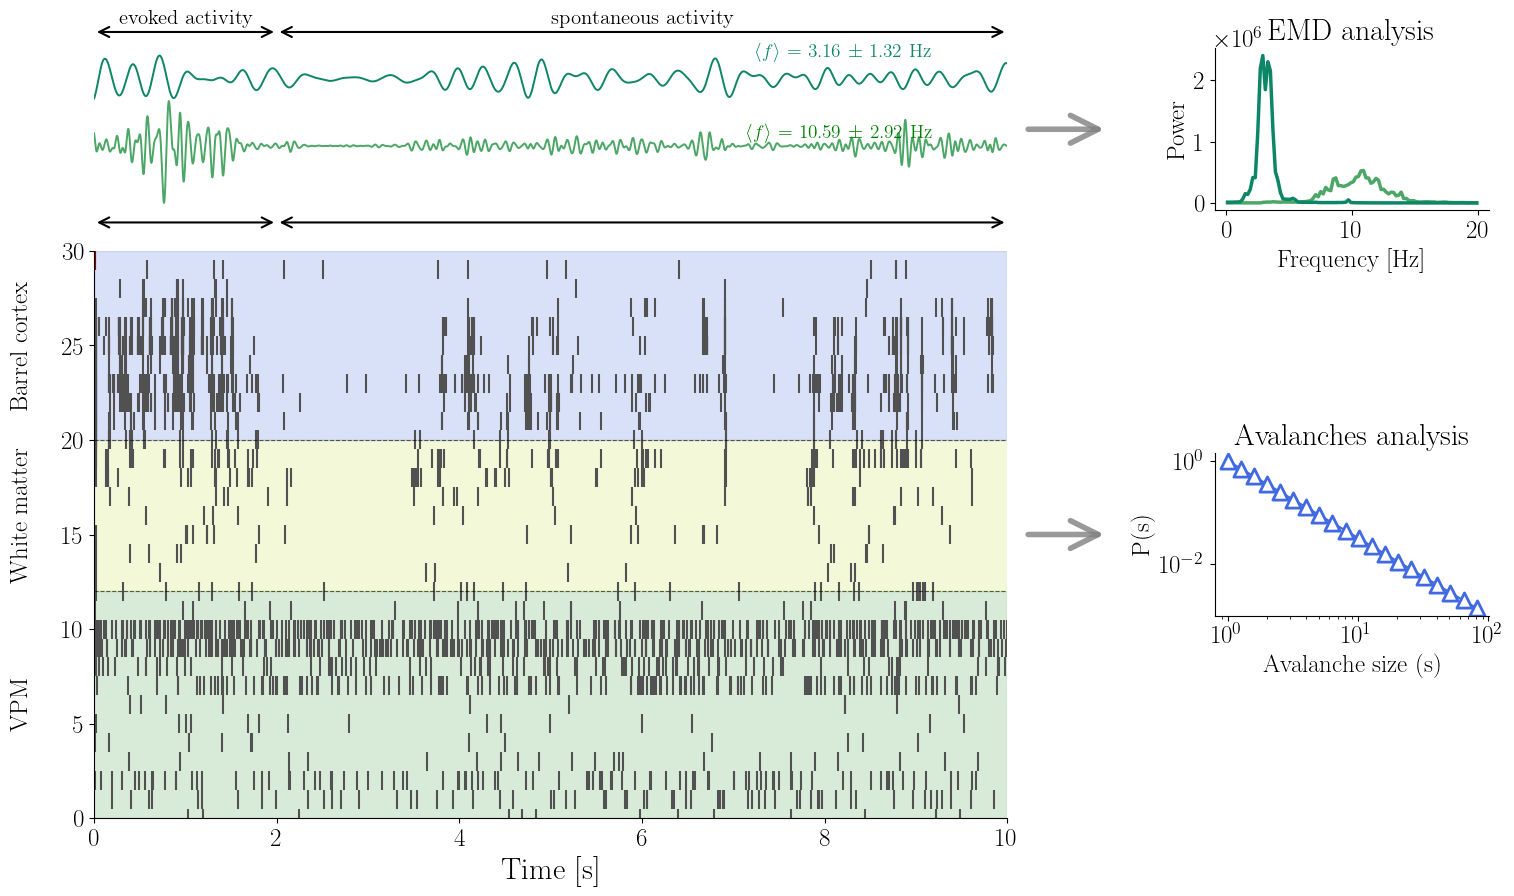

In [193]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.patches import FancyArrowPatch

# =========================
# PARAMETRI
# =========================
t_split = 2
t_end = T
pos =[]
for g in range(binspikes[trial].shape[0]):
    pos.append(np.where(binspikes[trial,g]>0)[0])
pos = np.asarray(pos)
times = np.arange(0, fs*T) / fs
pos_sec = [p/fs for p in pos]

# =========================
# FIGURA
# =========================
fig = plt.figure(figsize=(18,10))

gs = fig.add_gridspec(
    4, 2,
    height_ratios=[1, 1, 1.0,1.0],
    width_ratios=[2.0, 0.6],
    wspace=0.35,
    hspace=0.25
)


ax_top = fig.add_subplot(gs[0,0])

channel = 26

v = emd.sift.mask_sift(
    lfpTrials[0,channel,:],
    mask_freqs=30./fs,
    max_imfs=5
)

ax_top.plot(times, v[:,3]*0.02 + 10,
            color=cm.get_cmap('summer')(0.05), lw=1.4)

ax_top.plot(times, v[:,1]*0.02,
            color=cm.get_cmap('summer')(0.3), lw=1.4)

ax_top.set_xlim(0, t_end)
ax_top.axis('off')

# =========================
# FREQUENZE
# =========================
IP, IF, IA = emd.spectra.frequency_transform(v, fs, 'nht')

mean = np.average(IF[:,1], weights=IA[:,1])
std = np.sqrt(np.average((IF[:,1]-mean)**2, weights=IA[:,1]))

mean_ = np.average(IF[:,3], weights=IA[:,3])
std_ = np.sqrt(np.average((IF[:,3]-mean_)**2, weights=IA[:,3]))

ax_top.text(0.92, 0.45,
            rf'$\langle f \rangle$ = {mean:.2f} $\pm$ {std:.2f} Hz',
            transform=ax_top.transAxes,
            ha='right', color='green', fontsize=14)

ax_top.text(0.92, 0.95,
            rf'$\langle f \rangle$ = {mean_:.2f} $\pm$ {std_:.2f} Hz',
            transform=ax_top.transAxes,
            ha='right',
            color=cm.get_cmap('summer')(0.05),
            fontsize=14)

# ============================================================
# 🔻 BOTTOM SINISTRA (RASTER)
# ============================================================
ax_bottom = fig.add_subplot(gs[1:,0])

ax_bottom.eventplot(pos_sec, colors=cm.Greys(0.75))

ax_bottom.set_xlim(0, t_end)
ax_bottom.set_ylim(0, 30)
ax_bottom.set_xlabel('Time [s]', fontsize =22)

ax_bottom.axhspan(0, 12, color=cm.get_cmap('summer')(0.4), alpha=0.25)
ax_bottom.axhspan(12, 20, color=cm.get_cmap('summer')(0.8), alpha=0.25)
ax_bottom.axhspan(20, 30, color='royalblue', alpha=0.2)

ax_bottom.hlines([12,20], 0, t_end,
                 colors='k', linestyles='dashed', lw=0.8, alpha=0.6)

centers = [6, 16, 25]
labels = ['VPM', 'White matter', 'Barrel cortex']

for y, lab in zip(centers, labels):
    ax_bottom.text(-0.08, y, lab,
                   transform=ax_bottom.get_yaxis_transform(),
                   rotation=90, va='center', ha='center', fontsize=18)

ax_bottom.vlines(0, 29, 30, color='darkred', lw=3)

# ============================================================
#  HHT (TOP DESTRA)
# ============================================================
ax_hht = fig.add_subplot(gs[0,1])

hht_f, spec = emd.spectra.hilberthuang(
    IF, IA,
    freq_range,
    mode='density',
    sum_imfs=False,
    sum_time=True
)

ax_hht.plot(hht_f, spec[:,1],
            lw=2.5,
            color=cm.get_cmap('summer')(0.3))

ax_hht.plot(hht_f, spec[:,3],
            lw=2.5,
            color=cm.get_cmap('summer')(0.05))

ax_hht.set_title('EMD analysis',)
ax_hht.set_xlabel('Frequency [Hz]')
ax_hht.set_ylabel('Power')

# ============================================================
#  AVALANCHES (CENTRO DESTRA — PICCOLO)
# ============================================================
ax_av = fig.add_subplot(gs[2,1])  

s = np.logspace(0, 2, 200)[::10]
alpha = 1.5
ns = s**(-alpha)

ax_av.plot(s, ns,'-',
             color='royalblue'
            ,zorder=1 )

ax_av.scatter(s, ns,marker='^',s=120,facecolor='white',edgecolor='royalblue',  linewidths=2)



ax_av.set_yscale('log')
ax_av.set_xscale('log')


ax_av.set_xlabel('Avalanche size (s)')
ax_av.set_ylabel('P(s)')
ax_av.set_title('Avalanches analysis')

#ax_av.grid(True, which='both', alpha=0.2)

# ============================================================
# FRECCIA 1: OSCILLAZIONI → HHT
# ============================================================
pos_top = ax_top.get_position()
pos_hht = ax_hht.get_position()

arrow1 = FancyArrowPatch(
    (pos_top.x1+0.01, (pos_top.y0 + pos_top.y1)/2),
    (pos_hht.x0-0.06, (pos_hht.y0 + pos_hht.y1)/2),
    transform=fig.transFigure,
    arrowstyle='->',
    lw=4,
    color='grey',
    mutation_scale=50,
    alpha=0.8
)

fig.add_artist(arrow1)

# ============================================================
#  FRECCIA 2: RASTER → AVALANCHES
# ============================================================
pos_raster = ax_bottom.get_position()
pos_av = ax_av.get_position()

arrow2 = FancyArrowPatch(
    (pos_raster.x1 +0.01, (pos_raster.y0 + pos_raster.y1)/2),
    (pos_av.x0-0.06, (pos_av.y0 + pos_av.y1)/2),
    transform=fig.transFigure,
    arrowstyle='->',
    lw=4,
    color='grey',
    mutation_scale=50,
    alpha=0.8
)
# =========================
# FRECCE EVOKED / SPONTANEOUS (TOP)
# =========================
y_arrow = 1.1

ax_top.annotate(
    '', xy=(t_split, y_arrow), xytext=(0, y_arrow),
    xycoords=('data','axes fraction'),
    arrowprops=dict(arrowstyle='<->', lw=1.5, color='black')
)

ax_top.text(
    t_split/2, y_arrow+0.05,
    'evoked activity',fontsize =15,
    ha='center',
    transform=ax_top.get_xaxis_transform()
)

ax_top.annotate(
    '', xy=(t_end, y_arrow), xytext=(t_split, y_arrow),
    xycoords=('data','axes fraction'),
    arrowprops=dict(arrowstyle='<->', lw=1.5, color='black')
)

ax_top.text(
    (t_split+t_end)/2, y_arrow+0.05,
    'spontaneous activity',
    ha='center',fontsize =15,
    transform=ax_top.get_xaxis_transform()
)

# =========================
# FRECCE EVOKED / SPONTANEOUS (BOTTOM)
# =========================
y_arrow = 1.05

ax_bottom.annotate(
    '', xy=(t_split, y_arrow), xytext=(0, y_arrow),
    xycoords=('data','axes fraction'),
    arrowprops=dict(arrowstyle='<->', lw=1.5, color='black')
)

ax_bottom.text(
    t_split/2, y_arrow+0.05,
    '',
    ha='center',
    transform=ax_bottom.get_xaxis_transform()
)

ax_bottom.annotate(
    '', xy=(t_end, y_arrow), xytext=(t_split, y_arrow),
    xycoords=('data','axes fraction'),
    arrowprops=dict(arrowstyle='<->', lw=1.5, color='black')
)

ax_bottom.text(
    (t_split+t_end)/2, y_arrow+0.05,
    '',
    ha='center',
    transform=ax_bottom.get_xaxis_transform()
)
fig.add_artist(arrow2)

# =========================
# FINAL
# =========================
plt.tight_layout()
# channel 26 di rat  0 su memoria esterna
path_fig = "C:/Users/Benedetta/Desktop/Criticality in barrel cortex/Thalamus/Paper Figures/"
#plt.savefig(path_fig + 'Figura 1.jpg', dpi = 300, bbox_inches ='tight')
#plt.savefig(path_fig + 'Figura 1.tif', dpi = 300, bbox_inches ='tight')


In [177]:
plt.rcParams['font.size']=18

In [180]:
trial

0